In [1]:
import os, math
import time
import multiprocessing as multipr
from concurrent.futures import ProcessPoolExecutor
from typing import Optional, Tuple
import matplotlib.pyplot as plt

import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.integrate import quad
from scipy.optimize import minimize, minimize_scalar
import scipy.stats as st
from scipy.stats import norm
from scipy.special import betainc  # regularized incomplete beta I_x(a,b)
from scipy.special import beta as beta_fn
from scipy.special import roots_jacobi  # for Gauss–Jacobi on (0,1) weight
import warnings
import mpmath as mp
mp.mp.dps = 50

In [2]:


# -------------------- worker helpers (top-level & picklable) --------------------
def _init_worker():
    # prevent BLAS oversubscription inside workers
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")


In [3]:

def tukey_gh_sample(n, mu=0.0, sigma=0.0, g=0.0, h=0.0, random_state=None, Z=None):
    """
    Sample from the Tukey g-and-h distribution.
    
    Parameters
    ----------
    n : int
        Number of samples.
    mu : float
        Location parameter.
    sigma : float
        Scale parameter.
    g : float
        Skewness parameter.
    h : float
        Tail heaviness parameter.
    random_state : int or None
        Seed for reproducibility.
        
    Returns
    -------
    x : np.ndarray, shape (n,)
        Samples from the g-and-h distribution.
    """
    rng = np.random.default_rng(random_state)
    if Z is None:
        Z = rng.standard_normal(n)
    
    if g != 0:
        Y = (np.exp(g * Z) - 1) / g
    else:
        Y = Z
    X = mu + sigma * Y * np.exp(h * Z**2 / 2)
    return X


import numpy as np

def tukey_gh_sample_with_grads(n, mu=0.0, sigma=0.0, g=0.0, h=0.0, random_state=None, Z=None):
    """
    Sample from the Tukey g-and-h distribution and return gradients of the
    samples w.r.t. parameters (mu, sigma, g, h).
    """
    rng = np.random.default_rng(random_state)
    if Z is None:
        Z = rng.standard_normal(n)

    # Compute Y and dY/dg
    if g != 0:
        Y = (np.exp(g * Z) - 1) / g
        dY_dg = (g * Z * np.exp(g * Z) - (np.exp(g * Z) - 1)) / (g**2)
    else:
        Y = Z
        dY_dg = 0.5 * Z**2  # limit as g->0
    exp_h = np.exp(h * Z**2 / 2.0)

    X = mu + sigma * Y * exp_h

    # Gradients
    dX_dmu = np.ones_like(Z)
    dX_dsigma = Y * exp_h
    dX_dg = sigma * dY_dg * exp_h
    dX_dh = sigma * Y * (Z**2 / 2.0) * exp_h

    # grads = {
    #     "mu": dX_dmu,
    #     "sigma": dX_dsigma,
    #     "g": dX_dg,
    #     "h": dX_dh,
    # }
    grads = np.array([dX_dmu,dX_dsigma,dX_dg,dX_dh])

    return X, grads





In [4]:

def tukey_gh_ppf(p, mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """Quantile function Q(p) of Tukey g-and-h."""
    z = norm.ppf(p)
    if g != 0.0:
        y = (np.exp(g * z) - 1.0) / g
    else:
        y = z
    return mu + sigma * y * np.exp(0.5 * h * z**2)


def tukey_gh_pdf(x, mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """Numerical PDF of Tukey g-and-h using change of variables."""
    # Find corresponding z via inverse transformation
    # We solve Q(p) = x, where z = Phi^{-1}(p).
    # Equivalent: x = mu + sigma * T(z)
    # So we can map x back to z numerically.
    # But easier: compute density directly via dQ/dz and normal density.

    # z -> transformation
    def t(z):
        if g != 0:
            return (np.exp(g * z) - 1) / g * np.exp(0.5 * h * z**2)
        else:
            return z * np.exp(0.5 * h * z**2)

    def dt_dz(z):
        if g != 0:
            term1 = np.exp(g*z) * np.exp(0.5*h*z**2)
            term2 = ((np.exp(g*z)-1)/g) * (h*z*np.exp(0.5*h*z**2))
            return term1 + term2
        else:
            return np.exp(0.5*h*z**2) * (1 + h*z**2)

    # Map z -> x
    # z = st.norm.ppf(st.norm.cdf((x-mu)/sigma))  # initial guess: not exact
    # Actually easier: just invert using z grid
    z_grid = np.linspace(-6,6,20001)
    x_grid = mu + sigma * t(z_grid)
    pdf_vals = st.norm.pdf(z_grid) / (sigma * dt_dz(z_grid))

    # Interpolate
    return np.interp(x, x_grid, pdf_vals)


# E[exp(a Z + b Z^2)] for Z~N(0,1), valid for 2b < 1
# = (1 - 2b)^(-1/2) * exp( a^2 / (2(1 - 2b)) )
def _E_exp_aZ_bZ2(a, b):
    # assume float64; user ensures 2b < 1
    s = 1.0 - 2.0*b
    return s**(-0.5) * np.exp( (a*a) / (2.0*s) )

def _expm1_over_x(x):
    # stable (exp(x)-1)/x, with x→0 -> 1
    out = np.ones_like(x, dtype=float)
    mask = np.abs(x) > 1e-12
    out[mask] = np.expm1(x[mask]) / x[mask]
    return out

def tukey_gh_moments_stable(mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """
    Returns (E[t], E[t^2]) for t(Z) = ((exp(gZ)-1)/g) * exp(0.5*h*Z^2), Z~N(0,1).
    Stable for small |g| and h near 0 (but requires h<1 for E[t], h<1/2 for E[t^2]).
    """
    g = float(g)
    h = float(h)

    if h >= 1.0 - 1e-15:
        raise ValueError("E[t] diverges for h >= 1.")
    if h >= 0.5 - 1e-15:
        # E[t^2] diverges at/above 1/2; we still can compute E[t] if needed.
        # We'll return np.inf for E[t^2].
        second_diverges = True
    else:
        second_diverges = False

    # ---- E[t] ----
    # E[t] = ( E[exp(gZ + (h/2)Z^2)] - E[exp((h/2)Z^2)] ) / g
    # Let s1 = 1-h, x1 = g^2/(2*s1)
    s1 = 1.0 - h
    x1 = (g*g) / (2.0 * s1)
    pref1 = s1**(-0.5)                      # 1/sqrt(1-h)
    # Use expm1 to avoid cancellation when x1 small
    if np.abs(g) < 1e-12:
        E_t = 0.0  # exact odd moment limit as g->0
    else:
        E_t = pref1 * np.expm1(x1) / g

    # ---- E[t^2] ----
    if second_diverges:
        E_t2 = np.inf
    else:
        # E[t^2] = ( E[exp(2gZ + hZ^2)] - 2 E[exp(gZ + hZ^2)] + E[exp(hZ^2)] ) / g^2
        # Let s2 = 1 - 2h, x = g^2 / (2*s2).
        s2 = 1.0 - 2.0*h
        x = (g*g) / (2.0 * s2)
        pref2 = s2**(-0.5)                  # 1/sqrt(1-2h)
        if np.abs(g) < 1e-12:
            # limit g->0: E[Z^2 exp(h Z^2)] = (1-2h)^(-3/2)
            E_t2 = s2**(-1.5)
        else:
            # Compute expr = exp(4x) - 2 exp(x) + 1 in a stable way:
            # factor by max exponent to avoid overflow
            m = max(4.0*x, x, 0.0)
            expr = np.exp(4.0*x - m) - 2.0*np.exp(x - m) + np.exp(-m)
            E_t2 = pref2 * np.exp(m) * (expr / (g*g))

    m1_t = mu + sigma * E_t
    m2_t = mu**2 + 2*mu*sigma*E_t + sigma**2 * E_t2
    return m1_t, m2_t

In [5]:
def empirical_order_stat_moment_mp(k, N, x, r=1, dps=50):
    """
    High-precision version using mpmath for the same quantity as above.
    """
    if not (1 <= k <= N):
        raise ValueError("k must be in 1..N")
    mp.dps = dps
    x_sorted = np.sort(np.asarray(x, dtype=float))
    M = x_sorted.size
    if M == 0:
        raise ValueError("x must be non-empty")

    def I(t):
        if t <= 0.0: return mp.mpf('0')
        if t >= 1.0: return mp.mpf('1')
        return mp.betainc(k, N + 1 - k, 0, t, regularized=True)

    vals = []
    for j in range(1, M + 1):
        t_hi = j / M
        t_lo = (j - 1.0) / M
        wj = I(t_hi) - I(t_lo)
        vals.append(float(wj) * (x_sorted[j - 1] ** r))

    return float(sum(vals))


def empirical_order_stat_moment_sc(k, N, x, r=1):
    """
    E[X_(k)^r] when the parent distribution is the empirical CDF of data x (len M),
    and the sample size for the order statistic is N (k in 1..N).

    Parameters
    ----------
    k : int         # order (1..N)
    N : int         # sample size whose k-th order statistic we consider
    x : array-like  # data defining the empirical CDF (length M can be != N)
    r : float       # moment order (default 1)

    Returns
    -------
    float
    """
    if not (1 <= k <= N):
        raise ValueError("k must be in 1..N")
    x_sorted = np.sort(np.asarray(x, dtype=float))
    M = x_sorted.size
    if M == 0:
        raise ValueError("x must be non-empty")

    # breakpoints in p-space are j/M
    j = np.arange(1, M + 1, dtype=float)
    t_hi = j / M
    t_lo = (j - 1.0) / M

    # weights w_j = I_{t_hi}(k, N+1-k) - I_{t_lo}(k, N+1-k)
    w = betainc(k, N + 1 - k, t_hi) - betainc(k, N + 1 - k, t_lo)

    return float(np.dot(w, x_sorted ** r))

def empirical_order_stat_moment(k, N, x, r=1, dps=50, ver='mp'):
    if ver == 'mp':
        return empirical_order_stat_moment_mp(k, N, x, r=r, dps=dps)
    return empirical_order_stat_moment_sc(k, N, x, r=r)

In [6]:
def _empirical_k(k, N, x, dps, ver):
    return empirical_order_stat_moment(k, N, x, r=1, dps=dps, ver=ver)

def build_m1is_empirical(N, x, dps=50, ver='mp', use_par=True, pool=None, chunksize=None):
    if not use_par:
        np.array([empirical_order_stat_moment(k+1, N, x, r=1, dps=dps, ver=ver) for k in range(N)])
    # with multipr.Pool() as pool:
    #     vals = pool.starmap(_tukey_k, [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)])
    args = [(k+1, N, x, dps, ver) for k in range(N)]
    if chunksize is None:
        chunksize = max(1, math.ceil(N / (4 * (multipr.cpu_count() or 1))))

    if pool is not None:
        vals = pool.starmap(_empirical_k, args, chunksize=chunksize)
        return np.array(vals)

    with multipr.Pool(initializer=_init_worker) as p:
        vals = p.starmap(_empirical_k, args, chunksize=chunksize)
    return np.array(vals)

In [7]:
# ---------- True W term ----------
def true_W_tukey_empirical(x, mu1, sigma1, g1, h1, q1is_1=None, nquad=200, dps=50, ver='sc', use_par=False, pool=None, chunksize=None):
    N = len(x)
    if q1is_1 is None or len(q1is_1) != N:
        q1is_1 = build_q1is_tukey(N, mu1, sigma1, g1, h1, dps=dps, nquad=nquad, ver=ver,
                                  use_par=use_par, pool=pool)
        
    m1_t, m2_t = tukey_gh_moments_stable(mu=mu1, sigma=sigma1, g=g1, h=h1)   # you already have this
    x_sorted = np.sort(x)
    return m2_t + np.mean(x**2) - 2.0 * np.sum(x_sorted * q1is_1)

# ---------- Expected W between Tukey g-h and empirical distribution ----------
def expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N,
                          m1is_1=None, m1is_emp=None, nquad=200, dps=50, ver='sc',
                          use_par=False, pool=None):
    if m1is_1 is None or len(m1is_1) != N:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, dps=dps, nquad=nquad, ver=ver,
                                  use_par=use_par, pool=pool)
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, dps=dps, ver=ver, use_par=use_par, pool=pool)
    m1_t, m2_t = tukey_gh_moments_stable(mu=mu1, sigma=sigma1, g=g1, h=h1)
    return float(m2_t + np.mean(x**2) - 2.0 * np.mean(m1is_1 * m1is_emp))

In [8]:
def _rel_step(x, base=1e-3):
    x = float(x)
    return max(base, abs(x) * base)
    
def expected_W_tukey_empirical_grad(
    x, mu1, sigma1, g1, h1, N, idx=0,
    base_m1is_tukey=None, m1is_emp=None,  # supply to reuse across calls
    nquad=200, dps=50, ver='sc', use_par=False, pool=None
):
    """
    Central-difference gradient of expected_W_tukey_empirical w.r.t Tukey params:
    idx: 0=mu1, 1=sigma1, 2=g1, 3=h1
    """
    if idx not in (0,1,2,3):
        raise ValueError("idx must be in {0,1,2,3}")

    # Precompute empirical order-stat means once
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, dps=dps, ver=ver, use_par=use_par, pool=pool)

    # For mu/sigma, reuse base Tukey order-stat transform at (0,1,g1,h1)
    if idx in (0,1) and base_m1is_tukey is None:
        base_m1is_tukey = build_m1is_tukey(N, 0.0, 1.0, g1, h1, dps=dps, nquad=nquad,
                                           ver=ver, use_par=use_par, pool=pool)

    # Choose relative step
    if idx == 0:
        eps = _rel_step(mu1)
        mu_p, mu_m = mu1 + eps, mu1 - eps
        # Use affine shortcut for m1is_1
        m1is_p = mu_p + sigma1 * base_m1is_tukey
        m1is_m = mu_m + sigma1 * base_m1is_tukey
        fp = expected_W_tukey_empirical(x, mu_p, sigma1, g1, h1, N,
                                   m1is_1=m1is_p, m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver,
                                   use_par=False)
        fm = expected_W_tukey_empirical(x, mu_m, sigma1, g1, h1, N, 
                                   m1is_1=m1is_m, m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver,
                                   use_par=False)
    elif idx == 1:
        eps = _rel_step(sigma1)
        s_p, s_m = sigma1 + eps, max(1e-15, sigma1 - eps)
        m1is_p = mu1 + s_p * base_m1is_tukey
        m1is_m = mu1 + s_m * base_m1is_tukey
        fp = expected_W_tukey_empirical(x, mu1, s_p, g1, h1, N, 
                                   m1is_1=m1is_p, m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver,
                                   use_par=False)
        fm = expected_W_tukey_empirical(x, mu1, s_m, g1, h1, N, 
                                   m1is_1=m1is_m, m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver,
                                   use_par=False)
    elif idx == 2:
        eps = _rel_step(g1)
        fp = expected_W_tukey_empirical(x, mu1, sigma1, g1 + eps, h1, N, 
                                   m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver, use_par=use_par, pool=pool)
        fm = expected_W_tukey_empirical(x, mu1, sigma1, g1 - eps, h1, N, 
                                   m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver, use_par=use_par, pool=pool)
    else:  # idx == 3
        eps = _rel_step(h1)
        # ensure integrability if your tukey moments require h<1
        fp = expected_W_tukey_empirical(x, mu1, sigma1, g1, h1 + eps, N,
                                   m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver, use_par=use_par, pool=pool)
        fm = expected_W_tukey_empirical(x, mu1, sigma1, g1, h1 - eps, N, 
                                   m1is_emp=m1is_emp, nquad=nquad, dps=dps, ver=ver, use_par=use_par, pool=pool)

    return (fp - fm) / (2.0 * eps)


def expected_W_tukey_empirical_grad_gh(x, mu1, sigma1, g1, h1, N, m1is_emp=None, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, dps=dps, ver=ver, use_par=use_par, pool=pool)
    grad = np.empty(2)
    for i, idx in enumerate([2,3]):
        grad[i] = expected_W_tukey_empirical_grad(x, mu1, sigma1, g1, h1, N, idx=idx, m1is_emp=m1is_emp, 
                                                    dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad


def expected_W_tukey_empirical_grad_4d(x, mu1, sigma1, g1, h1, N, base_m1is_1=None, m1is_emp=None, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    if base_m1is_1 is None:
        base_m1is_1 = build_m1is_tukey(N, 0., 1., g1, h1, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, dps=dps, ver=ver, use_par=use_par, pool=pool)
    grad = np.empty(4)
    for idx in range(4):
        grad[idx] = expected_W_tukey_empirical_grad(x, mu1, sigma1, g1, h1, N, idx=idx, base_m1is_tukey=base_m1is_1, m1is_emp=m1is_emp, 
                                                    dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad

In [9]:
def numerical_sol_true_loss_empirical_4d(x,
                         ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    def objective(params):
        mu1, sigma1, g1, h1 = params
        
        return float(true_W_tukey_empirical(x, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool))
        
    res = minimize(objective, x0=[0.0, 1.0, 0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, np.inf), (-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_true_loss_empirical_2d(x, mu1, sigma1, 
                         ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    def objective(params):
        g1, h1 = params
        
        return float(true_W_tukey_empirical(x, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool))
        
    res = minimize(objective, x0=[0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_true_loss_empirical_1d(x, mu1, sigma1, g1, h1, opt_idx: int, 
                         ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, use_par=False, pool=None, chunksize=None):
    # convenience wrapper around the user‑supplied objective
    def _obj(params, _mu1=mu1, _sigma1=sigma1, _g1=g1, _h1=h1):
        mu1, sigma1, g1, h1 = _mu1, _sigma1, _g1, _h1
        if opt_idx == 0:
            mu1 = params
        elif opt_idx == 1:
            sigma1 = params
        elif opt_idx == 2:
            g1 = params
        elif opt_idx == 3:
            h1 = params
        
        return float(true_W_tukey_empirical(x, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool))

    if opt_idx == 0:
        bounds = (-1e9, 1e9)
    elif opt_idx == 1:
        bounds = (0, 1e9)
    elif opt_idx == 2:
        bounds = (-1e1, 1e1)
    elif opt_idx == 3:
        bounds = (0, 0.5-eps)
        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=bounds,
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def numerical_sol_expected_loss_empirical_4d(x, N, alpha = 0,
                        m1is_emp = None, ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, ver=ver, use_par=use_par, pool=pool)
    def objective(params):
        mu1, sigma1, g1, h1 = params
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver)) \
            - alpha * float(expected_W_tukey(g1, h1, g1, h1, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_1, ver=ver))
        return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver))
        
    res = minimize(objective, x0=[0.0, 1.0, 0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, np.inf), (-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_empirical_2d(x, mu1, sigma1, N, 
                         alpha = 0,
                        m1is_emp = None, ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, ver=ver, use_par=use_par, pool=pool)
    def objective(params):
        g1, h1 = params
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver)) \
            - alpha * float(expected_W_tukey(g1, h1, g1, h1, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_1, ver=ver))
        return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver))
        
    res = minimize(objective, x0=[0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_empirical_1d(x, mu1, sigma1, g1, h1, opt_idx: int, N, 
                         alpha = 0,
                        m1is_emp = None, ver = 'sc',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, bounds=None, use_par=False, pool=None, chunksize=None, debug=False):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    if m1is_emp is None or len(m1is_emp) != N:
        m1is_emp = build_m1is_empirical(N, x, ver=ver, use_par=use_par, pool=pool)
    # convenience wrapper around the user‑supplied objective
    def _obj(params, _mu1=mu1, _sigma1=sigma1, _g1=g1, _h1=h1):
        mu1, sigma1, g1, h1 = _mu1, _sigma1, _g1, _h1
        if opt_idx == 0:
            mu1 = params
        elif opt_idx == 1:
            sigma1 = params
        elif opt_idx == 2:
            g1 = params
        elif opt_idx == 3:
            h1 = params
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver)) \
            - alpha * float(expected_W_tukey(g1, h1, g1, h1, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_1, ver=ver))
        return float(expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_1=m1is_1, m1is_emp=m1is_emp, ver=ver))

    if bounds is None:
        if opt_idx == 0:
            bounds = (-1e9, 1e9)
        elif opt_idx == 1:
            bounds = (0, 1e9)
        elif opt_idx == 2:
            bounds = (-2.5, 2.5)
        elif opt_idx == 3:
            bounds = (0, 0.5-eps)
        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=bounds,
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    if debug:
        return res
    return float(res.x), float(res.fun)

In [10]:
# ---------------- helpers ----------------
def _apply_param(mu1, sigma1, g1, h1, idx, param):
    if idx == 0: mu1 = param
    elif idx == 1: sigma1 = param
    elif idx == 2: g1 = param
    elif idx == 3: h1 = param
    return mu1, sigma1, g1, h1

# ---------------- TOP-LEVEL workers (picklable) ----------------
def _submit_true_cell(args):
    (param, idx, base_mu1, base_sigma1, base_g1, base_h1, x, ver, i) = args
    mu1, sigma1, g1, h1 = _apply_param(base_mu1, base_sigma1, base_g1, base_h1, idx, param)
    val = true_W_tukey_empirical(x, mu1, sigma1, g1, h1, ver=ver)
    return i, float(val)

def _submit_emp_dist_cell(args):
    (N, param, idx, base_mu1, base_sigma1, base_g1, base_h1,
     x, ver, j, i) = args
    mu1, sigma1, g1, h1 = _apply_param(base_mu1, base_sigma1, base_g1, base_h1, idx, param)
    val = expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N,
                                      ver=ver)
    return j, i, float(val)

# ---------------- main (flat, cell-wise parallel) ----------------
def loss_plots_empirical_flat(x, mu1, sigma1, g1, h1, opt_idx, 
                            param_set, Nset=(5,10,20,50,100), ver='sc', minimizer=True):
    param_set = list(param_set)
    Nset = list(Nset)

    I, J = len(param_set), len(Nset)
    true_dists = np.empty(I, dtype=float)
    emp_dists = np.empty((J, I), dtype=float)
    emp_sols  = np.empty(J, dtype=float)
    emp_vals  = np.empty(J, dtype=float)
    true_sols, true_vals = 0, 0

    start = time.time()
    # 2) True curve over param_set (flat tasks)
    true_tasks = [(param_set[i], opt_idx, mu1, sigma1, g1, h1, x, ver, i)
                  for i in range(I)]
    with ProcessPoolExecutor(max_workers=os.cpu_count(), initializer=_init_worker) as ex:
        for i, val in ex.map(_submit_true_cell, true_tasks):
            true_dists[i] = val
    print("dist true: ", time.time() - start)
    
    start = time.time()
    # 4) Empirical distances over all (N, param) cells (flat tasks)
    cell_tasks = []
    for j, N in enumerate(Nset):
        for i, p in enumerate(param_set):
            cell_tasks.append((N, p, opt_idx, mu1, sigma1, g1, h1,
                               x, ver, j, i))
    with ProcessPoolExecutor(max_workers=os.cpu_count(), initializer=_init_worker) as ex:
        for j, i, val in ex.map(_submit_emp_dist_cell, cell_tasks):
            emp_dists[j, i] = val
    print("dist emp: ", time.time() - start)

    if minimizer:
        start = time.time()
        
        with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
            for j, N in enumerate(Nset):
                curidx = np.argmin(emp_dists[j])
                bounds = (param_set[max(0, curidx-1)], param_set[min(curidx+1, len(param_set)-1)])
                emp_sols[j], emp_vals[j] = numerical_sol_expected_loss_empirical_1d(x, mu1, sigma1, g1, h1, opt_idx, 
                                     N, alpha = 0, bounds=bounds, ver=ver, use_par=True, pool=pool)
        print("solve emp: ", time.time() - start)
    
        start = time.time()
        # 5) (Optional) true optimizer
        with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
            true_sols, true_vals = numerical_sol_true_loss_empirical_1d(x, mu1, sigma1, g1, h1, opt_idx, ver=ver, use_par=True, pool=pool)
        print("solve true: ", time.time() - start)
    # 6) Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5.0, 3.6))
    plt.plot(param_set, true_dists, label='True')
    if minimizer:
        plt.scatter(true_sols, true_vals)

    for j, N in enumerate(Nset):
        plt.plot(param_set, emp_dists[j, :], label=f'N={N}')
        if minimizer:
            plt.scatter(emp_sols[j], emp_vals[j])

    plt.legend()
    plt.grid(True)
    plt.xlabel(r'$a$', fontsize=12)
    plt.ylabel(r'$W$ / loss', fontsize=12)

    return {
        'param_set': param_set,
        'Nset': Nset,
        'true_dists': true_dists,
        'true_sols': true_sols,
        'true_vals': true_vals,
        'emp_dists': emp_dists,
        'emp_sols': emp_sols,
        'emp_vals': emp_vals,
    }

In [11]:
def minimise_alpha_var_empirical(x, mu1, sigma1, g1, h1, idx: int, 
                       N_set, m1is_emp_set = None, ver = 'sc',
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500, bounds=None, use_par=False, pool=None, chunksize=None, debug=False):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """

    if m1is_emp_set is None:
        m1is_emp_set = dict()
        for j, N in enumerate(N_set):
            m1is_emp_set[str(N)] = build_m1is_empirical(N, x, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    # convenience wrapper around the user‑supplied objective
    def _obj(param, _mu1=mu1, _sigma1=sigma1, _g1=g1, _h1=h1, _idx=idx):
        mu1, sigma1, g1, h1 = _mu1, _sigma1, _g1, _h1
        idx = _idx
        if idx == 0: mu1 = param
        elif idx == 1: sigma1 = param
        elif idx == 2: g1 = param
        elif idx == 3: h1 = param
        temp_alpha_set = np.empty(len(N_set))
        for j, N in enumerate(N_set):
            S_grad = expected_self_W_tukey_grad(mu1, sigma1, g1, h1, N, idx, ver=ver, use_par=use_par, pool=pool)
            J_MS_grad = expected_W_tukey_empirical_grad(x, mu1, sigma1, g1, h1, N, idx=idx, m1is_emp=m1is_emp_set[str(N)], ver=ver, use_par=use_par, pool=pool)
            temp_alpha = J_MS_grad / S_grad
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)

    if bounds is None:
        if idx == 0:
            bounds = (-10, 10)
        elif idx == 1:
            bounds = (0, 10)
        elif idx == 2:
            bounds = (-1, 1)
        elif idx == 3:
            bounds = (0, 0.5-eps)
        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=bounds,
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    if debug:
        return res
    return float(res.x), float(res.fun)



In [12]:
def minimise_alpha_var_empirical_2d(x, mu1, sigma1,  
                       N_set, m1is_emp_set = None, ver = 'sc',
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10, logver=False, logver2=False, reg=0, reg2=0,
                                     maxiter: int = 500, bounds=None, use_par=False, pool=None, chunksize=None, debug=False):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """

    if m1is_emp_set is None:
        m1is_emp_set = dict()
        for j, N in enumerate(N_set):
            m1is_emp_set[str(N)] = build_m1is_empirical(N, x, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    # convenience wrapper around the user‑supplied objective
    def _obj(param):
        g1, h1 = param
        temp_alpha_set = np.empty(len(N_set))
        temp_S_grad_set = np.empty((len(N_set), 2))
        temp_J_grad_set = np.empty((len(N_set), 2))
        temp_J_set = np.empty(len(N_set))
        for j, N in enumerate(N_set):
            S_grad = expected_self_W_tukey_grad_gh(mu1, sigma1, g1, h1, N, ver=ver, use_par=use_par, pool=pool)
            J_MS_grad = expected_W_tukey_empirical_grad_gh(x, mu1, sigma1, g1, h1, N, m1is_emp=m1is_emp_set[str(N)], ver=ver, use_par=use_par, pool=pool)
            
            temp_alpha = np.linalg.norm(J_MS_grad) / np.linalg.norm(S_grad)
            temp_alpha_set[j] = temp_alpha
            temp_S_grad_set[j] = S_grad
            temp_J_grad_set[j] = J_MS_grad
            if reg2 > 0:
                temp_J_set[j] = expected_W_tukey_empirical(x, mu1, sigma1, g1, h1, N, m1is_emp=m1is_emp_set[str(N)], ver=ver, use_par=use_par, pool=pool)
        if logver:
            return np.log(np.var(temp_alpha_set))
        elif logver2:
            return np.log(np.var(temp_J_grad_set/temp_S_grad_set, axis=0)).sum()
        return np.var(temp_alpha_set) + reg * np.mean(np.sum(temp_J_grad_set**2, axis=-1)) + reg2 * np.mean(temp_J_set)

        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize(_obj, x0=[0.1, 0.1], method="L-BFGS-B",
                   bounds=[(-0.5, 0.5), (0, 0.2)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    if debug:
        return res
    return res.x, float(res.fun)



In [34]:
def _one_cell(param, idx, base_mu1, base_sigma1, base_g1, base_h1,
              N, m1is_emp, x, ver):
    # set parameters
    mu1, sigma1, g1, h1 = base_mu1, base_sigma1, base_g1, base_h1
    if idx == 0: mu1 = param
    elif idx == 1: sigma1 = param
    elif idx == 2: g1 = param
    elif idx == 3: h1 = param

    S_grad    = expected_self_W_tukey_grad(mu1, sigma1, g1, h1, N, idx, ver=ver, use_par=False, pool=None)
    J_MS_grad = expected_W_tukey_empirical_grad(x, mu1, sigma1, g1, h1, N, idx=idx, 
                                                m1is_emp=m1is_emp, ver=ver, use_par=False, pool=None)
    return J_MS_grad / S_grad, S_grad, J_MS_grad

def _submit_cell(args):
    # unpack a single tuple task -> (i, j, alpha, S, J)
    (i, j, param, idx, base_mu1, base_sigma1, base_g1, base_h1,
     N, m1is_emp, x, ver) = args
    a, s, m = _one_cell(param, idx, base_mu1, base_sigma1, base_g1, base_h1,
                        N, m1is_emp, x, ver)
    return i, j, a, s, m

def get_alpha_dagger_empirical_parallel_flat(x, mu1, sigma1, g1, h1, idx, N_set, N_set2, param_set, ver='sc'):
    # precompute m1is_2 for each N (read-only)
    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        m1is_emp_set = {
            str(N): build_m1is_empirical(N, x, ver=ver, use_par=True, pool=pool)
            for N in N_set
        }

    I, J = len(param_set), len(N_set)
    temp_alpha_set = np.empty((I, J), dtype=float)
    S_grad_set     = np.empty((I, J), dtype=float)
    J_MS_set       = np.empty((I, J), dtype=float)

    # build flat task list (tuples only; no lambdas, no locals)
    tasks = []
    for i, p in enumerate(param_set):
        for j, N in enumerate(N_set):
            tasks.append((i, j, p, idx, mu1, sigma1, g1, h1,
                          N, m1is_emp_set[str(N)], x, ver))

    # IMPORTANT on Windows/macOS: guard with if __name__ == "__main__"
    with ProcessPoolExecutor() as ex:
        for i, j, a, s, m in ex.map(_submit_cell, tasks):
            temp_alpha_set[i, j] = a
            S_grad_set[i, j]     = s
            J_MS_set[i, j]       = m

    

    par_idx = np.argmin(temp_alpha_set.std(axis=-1))
    bounds=(param_set[max(0,par_idx-2)], param_set[min(par_idx+2, len(param_set)-1)])
    print("bounds: ", bounds)
    
    temp_alpha_heu_set = np.empty(len(N_set))
    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        param_heu, val = minimise_alpha_var_empirical(x, mu1, sigma1, g1, h1, idx, 
                       N_set, bounds=bounds, ver = ver,
                                   use_par=True, pool=pool)
        
        
        mu1, sigma1, g1, h1 = _apply_param(mu1, sigma1, g1, h1, idx, param_heu)
        for j, N in enumerate(N_set):
            S_grad_heu = expected_self_W_tukey_grad(mu1, sigma1, g1, h1, N, idx, ver=ver, use_par=True, pool=pool)
            J_MS_grad_heu = expected_W_tukey_empirical_grad(x, mu1, sigma1, g1, h1, N, idx=idx, m1is_emp=m1is_emp_set[str(N)], ver=ver, use_par=True, pool=pool)
            temp_alpha_heu = J_MS_grad_heu / S_grad_heu
            temp_alpha_heu_set[j] = temp_alpha_heu
            
        alpha_heu = np.mean(temp_alpha_heu_set)
    print(f"param_heu: {param_heu}")
    print(f"alpha_heu: {alpha_heu}")

    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        param_inf, _ = numerical_sol_true_loss_empirical_1d(x, mu1, sigma1, g1, h1, idx, ver=ver, use_par=True, pool=pool)
    print(f"param_inf: {param_inf}")
    param_uncorrected_set = np.empty(len(N_set2))
    param_corrected_a0_5 = np.empty(len(N_set2))
    param_corrected_a = np.empty(len(N_set2))
    temp_alphas = np.empty(len(N_set2))
    alpha = alpha_heu
    print(alpha)

    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        for i, N in enumerate(N_set2):
            if N not in N_set:
                 m1is_emp_set[str(N)] = build_m1is_empirical(N, x, ver=ver, use_par=True, pool=pool)
            # print(N)
            param_uncorrected_set[i], _ = numerical_sol_expected_loss_empirical_1d(x, mu1, sigma1, g1, h1, idx, 
                                             N, m1is_emp=m1is_emp_set[str(N)], alpha = 0, ver=ver, use_par=True, pool=pool)
            param_corrected_a0_5[i], _ = numerical_sol_expected_loss_empirical_1d(x, mu1, sigma1, g1, h1, idx, 
                                             N, m1is_emp=m1is_emp_set[str(N)], alpha = 0.5, ver=ver, use_par=True, pool=pool)
            param_corrected_a[i], _ = numerical_sol_expected_loss_empirical_1d(x, mu1, sigma1, g1, h1, idx, 
                                             N, m1is_emp=m1is_emp_set[str(N)], alpha = alpha, ver=ver, use_par=True, pool=pool)

    plt.figure(figsize=(4, 3))
    plt.scatter(param_set, np.std(temp_alpha_set, axis=-1))
    plt.scatter(param_heu, np.std(val))
    plt.grid()
    plt.xlabel(r'$a$', fontsize=12)
    plt.ylabel(r'$stdev[\alpha_{N}(a)]$', fontsize=12)
    
    plt.figure(figsize=(4,3))
    plt.axhline([param_inf], color='k', ls='--', label=r'$a^*$', zorder=20)
    plt.plot(N_set2, param_uncorrected_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
    plt.plot(N_set2, param_corrected_a0_5, label=r'$\alpha$=0.5', marker='o', zorder=3)
    plt.plot(N_set2, param_corrected_a, label=rf'$\alpha^\dagger$={alpha:.3f}', marker='o', zorder=5)
    plt.grid()
    plt.xlabel(f'N', fontsize=12)
    plt.ylabel(r'$\hat{a}_N$', fontsize=12)
    # plt.ylim(-1, -0.95)
    plt.legend()
    plt.show()
    
    res = dict()
    res['alpha_set'] = temp_alpha_set
    res['S_grad_set'] = S_grad_set
    res['J_MS_set'] = J_MS_set
    res['param_heu'] = param_heu
    res['alpha_heu'] = alpha_heu
    res['alpha_heu_set'] = temp_alpha_heu_set
    res['param_inf'] = param_inf
    res['N_set'] = N_set
    res['N_set2'] = N_set2
    res['param_set'] = param_set
    res['param_uncorrected_set'] = param_uncorrected_set
    res['param_corrected_a0_5'] = param_corrected_a0_5
    res['param_corrected_a'] = param_corrected_a
    return res

In [14]:
def tukey_order_stat_moment_mp(k, N, g, h, r, mu=0.0, sigma=1.0, dps=50):
    """
    E[X_(k)^r] for Tukey g-and-h via z-integral:
    1/B * ∫ (mu+sigma*t_g,h(z))^r * Phi(z)^(k-1) * (1-Phi(z))^(N-k) * phi(z) dz
    Valid if h < 1/r.
    """
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")
    mp.mp.dps = dps

    sqrt2 = mp.sqrt(2)
    inv_sqrt2pi = 1.0/mp.sqrt(2*mp.pi)

    def Phi(z):
        return 0.5 * (1 + mp.erf(z / sqrt2))

    def phi(z):
        return inv_sqrt2pi * mp.e**(-0.5*z*z)

    def t_gh(z):
        if g != 0:
            return ((mp.e**(g*z) - 1.0)/g) * mp.e**(0.5*h*z*z)
        else:
            return z * mp.e**(0.5*h*z*z)

    B = mp.beta(k, N+1-k)

    def integrand(z):
        p = Phi(z)
        # Stable weight: exp((k-1)log p + (N-k)log(1-p))
        # Guard p in (0,1) numerically:
        if p <= 0: 
            return mp.mpf('0')
        if p >= 1:
            return mp.mpf('0')
        logw = (k-1)*mp.log(p) + (N-k)*mp.log1p(-p)   # log(1-p) stable
        x = mu + sigma * t_gh(z)
        return (x**r) * mp.e**(logw) * phi(z)

    val = mp.quad(integrand, [-mp.inf, mp.inf])
    return float(val / B)




def tukey_order_stat_moment_sc(k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0, nquad=200):
    """
    E[X_{(k)}^r] for Tukey g-and-h via Gauss–Jacobi quadrature.
    Conditions: 1 <= k <= N and h < 1/r (moment existence).
    """
    if not (1 <= k <= N):
        raise ValueError("k must satisfy 1 <= k <= N")
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")

    # Jacobi nodes/weights on [-1,1] for weight (1-x)^alpha (1+x)^beta
    alpha = N - k     # power on (1-p)
    beta_ = k - 1     # power on p
    x, w = roots_jacobi(nquad, alpha, beta_)   # x in [-1,1]

    # Map to p in (0,1)
    p = (x + 1.0) / 2.0

    # Constant from change of variables:
    # ∫_0^1 p^beta (1-p)^alpha f(p) dp = 2^{-(alpha+beta+1)} * Σ w_i f(p_i)
    const = 2.0 ** (-(alpha + beta_ + 1.0))

    Q = tukey_gh_ppf(p, mu=mu, sigma=sigma, g=g, h=h)
    integral = const * np.dot(w, Q**r)
    return integral / beta_fn(k, N + 1 - k)

def tukey_order_stat_moment(k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0, dps=50, nquad=200, ver='mp'):
    if ver == 'mp':
        return tukey_order_stat_moment_mp(k, N, g, h, r, mu=mu, sigma=sigma, dps=dps)
    return tukey_order_stat_moment_sc(k, N, g=g, h=h, r=r, mu=mu, sigma=sigma, nquad=nquad)

def tukey_cross_moment_mp(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, dps=50):
    mp.mp.dps = dps

    sqrt2 = mp.sqrt(2)
    inv_sqrt2pi = 1.0/mp.sqrt(2*mp.pi)

    def Phi(z):
        return 0.5 * (1 + mp.erf(z / sqrt2))

    def phi(z):
        return inv_sqrt2pi * mp.e**(-0.5*z*z)

    def t_gh(z, g, h):
        if g != 0:
            return ((mp.e**(g*z) - 1.0)/g) * mp.e**(0.5*h*z*z)
        else:
            return z * mp.e**(0.5*h*z*z)

    def integrand(z):
        p = Phi(z)
        # Stable weight: exp((k-1)log p + (N-k)log(1-p))
        # Guard p in (0,1) numerically:
        if p <= 0: 
            return mp.mpf('0')
        if p >= 1:
            return mp.mpf('0')
        
        x1 = mu1 + sigma1 * t_gh(z, g1, h1)
        x2 = mu2 + sigma2 * t_gh(z, g2, h2)
        return (x1*x2) * phi(z)

    val = mp.quad(integrand, [-mp.inf, mp.inf])
    return float(val)

def _tukey_t(z, g, h, g_eps=1e-10):
    """t_{g,h}(z) with the g->0 limit handled."""
    if abs(g) < g_eps:
        return z * np.exp(0.5 * h * z * z)
    return ((np.exp(g * z) - 1.0) / g) * np.exp(0.5 * h * z * z)

def tukey_cross_moment_sc(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, nquad=200):
    """
    E[X1 * X2] with Xj = mu_j + sigma_j * t_{gj,hj}(Z),  Z ~ N(0,1).
    Uses scipy.integrate.quad over (-inf, inf).

    Requires h1 + h2 < 1 for integrability.
    """
    if h1 + h2 >= 1.0 - 1e-14:
        raise ValueError("Integral diverges: need h1 + h2 < 1.")

    inv_sqrt2pi = 1.0 / np.sqrt(2.0 * np.pi)

    def phi(z):
        return inv_sqrt2pi * np.exp(-0.5 * z * z)

    def integrand(z):
        t1 = _tukey_t(z, g1, h1)
        t2 = _tukey_t(z, g2, h2)
        x1 = mu1 + sigma1 * t1
        x2 = mu2 + sigma2 * t2
        return (x1 * x2) * phi(z)

    # quad over (-inf, inf); increase 'limit' for tougher (g,h)
    val, err = quad(integrand, -np.inf, np.inf, epsabs=1e-9, epsrel=1e-9, limit=nquad)
    return float(val)

def tukey_cross_moment(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, dps=50, nquad=200, ver='mp'):
    if ver == 'mp':
        return tukey_cross_moment_mp(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, dps=dps)
    return tukey_cross_moment_sc(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, nquad=nquad)

In [15]:
def _tukey_k(k, N, mu1, sigma1, g1, h1, dps, nquad, ver):
    return tukey_order_stat_moment(k, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver)

def build_m1is_tukey(N, mu1, sigma1, g1, h1, dps=50, nquad=200, ver='mp', use_par=True, pool=None, chunksize=None):
    if not use_par:
        np.array([tukey_order_stat_moment(k+1, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver) for k in range(N)])
    # with multipr.Pool() as pool:
    #     vals = pool.starmap(_tukey_k, [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)])
    args = [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)]
    if chunksize is None:
        chunksize = max(1, math.ceil(N / (4 * (multipr.cpu_count() or 1))))

    if pool is not None:
        vals = pool.starmap(_tukey_k, args, chunksize=chunksize)
        return np.array(vals)

    with multipr.Pool(initializer=_init_worker) as p:
        vals = p.starmap(_tukey_k, args, chunksize=chunksize)
    return np.array(vals)

In [16]:
def tukey_quantile_moment_mp(k, N, g, h, r=1, mu=0.0, sigma=1.0, dps=50):
    """
    Compute the (non-normalized) contribution of the r-th moment over the k-th
    equal-probability bin of a standard normal Z:
        ∫_{(k-1)/N}^{k/N} [mu + sigma * t_{g,h}(z)]^r * φ(z) dz,
    where t_{g,h}(z) = ((e^{g z}-1)/g) * e^{(h/2) z^2} if g!=0 else z * e^{(h/2) z^2}.
    Valid for r>0 only if h < 1/r (moment existence condition).
    """
    if not (1 <= k <= N):
        raise ValueError("k must be in 1..N")
    if r <= 0:
        raise ValueError("this helper assumes r > 0")
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")

    mp.dps = dps

    # quantile bounds v1, v2
    v1, v2 = (k-1)/N, k/N

    # inverse standard normal via erfinv: Φ^{-1}(p) = √2 * erfinv(2p-1)
    def ppf_standard_normal(p):
        if p <= 0.0:
            return -mp.inf
        if p >= 1.0:
            return mp.inf
        return mp.sqrt(2) * mp.erfinv(2*p - 1)

    z1 = ppf_standard_normal(v1)
    z2 = ppf_standard_normal(v2)

    inv_sqrt2pi = 1.0 / mp.sqrt(2 * mp.pi)
    def phi(z):
        return inv_sqrt2pi * mp.e**(-0.5 * z*z)

    def t_gh(z):
        # Tukey g-and-h transform
        if g != 0:
            return ((mp.e**(g * z) - 1.0) / g) * mp.e**(0.5 * h * z * z)
        else:
            return z * mp.e**(0.5 * h * z * z)

    def integrand(z):
        x = mu + sigma * t_gh(z)
        return (x ** r) * phi(z)

    # integrate over [z1, z2], allowing infinite bounds
    val = mp.quad(integrand, [z1, z2])
    return float(val)

def tukey_quantile_moment_sc(
    k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0,
    method="legendre", nquad=200, return_average=False
):
    """
    Bin moment for Tukey g-and-h over the k-th equal-probability bin:
        I_k = ∫_{(k-1)/N}^{k/N} [mu + sigma * t_{g,h}(Φ^{-1}(p))]^r dp
    Valid for r>0 only if h < 1/r.

    Args:
        k, N : 1 <= k <= N
        g,h,mu,sigma : Tukey g-h and affine params
        r : moment order (>0)
        method : 'quad' (adaptive) or 'legendre' (fixed Gauss–Legendre)
        nquad : nodes for 'legendre'
        return_average : if True, returns N * I_k (the average over the bin)

    Returns:
        float : I_k (or N*I_k if return_average=True)
    """
    if not (1 <= k <= N):
        raise ValueError("k must satisfy 1 <= k <= N")
    if r <= 0:
        raise ValueError("r must be > 0")
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")

    a, b = (k - 1) / N, k / N  # p-interval

    def integrand_p(p):
        # guard against endpoints p=0 or p=1 in any adaptive sampling
        p = np.clip(p, np.nextafter(0.0, 1.0), np.nextafter(1.0, 0.0))
        z = norm.ppf(p)
        x = mu + sigma * _tukey_t(z, g=g, h=h)
        return x**r

    if method == "quad":
        val, err = quad(integrand_p, a, b, epsabs=1e-10, epsrel=1e-8, limit=200)
    elif method == "legendre":
        # Map Gauss–Legendre nodes x∈[-1,1] to p∈[a,b]
        x, w = leggauss(nquad)
        p = 0.5 * (b - a) * x + 0.5 * (b + a)
        vals = integrand_p(p)
        val = 0.5 * (b - a) * np.dot(w, vals)
    else:
        raise ValueError("method must be 'quad' or 'legendre'")

    if return_average:
        return float(N * val)  # average over the bin
    return float(val)


def tukey_quantile_moment(k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0, dps=50, nquad=200, ver='mp', method="legendre"):
    if ver == 'mp':
        return tukey_quantile_moment_mp(k, N, g, h, r=1, mu=mu, sigma=sigma, dps=dps)
    return tukey_quantile_moment_sc(k, N, g=g, h=h, r=1, mu=mu, sigma=sigma, nquad=nquad, method=method)

In [17]:
def _tukey_k_quantile(k, N, mu1, sigma1, g1, h1, dps, nquad, ver, method):
    return tukey_quantile_moment(k, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver, method=method)

def build_q1is_tukey(N, mu1, sigma1, g1, h1, dps=50, nquad=200, ver='mp', method="legendre", use_par=True, pool=None, chunksize=None):
    if not use_par:
        np.array([tukey_quantile_moment(k+1, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver, method=method) for k in range(N)])
    # with multipr.Pool() as pool:
    #     vals = pool.starmap(_tukey_k, [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)])
    args = [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver, method) for k in range(N)]
    if chunksize is None:
        chunksize = max(1, math.ceil(N / (4 * (multipr.cpu_count() or 1))))

    if pool is not None:
        vals = pool.starmap(_tukey_k_quantile, args, chunksize=chunksize)
        return np.array(vals)

    with multipr.Pool(initializer=_init_worker) as p:
        vals = p.starmap(_tukey_k_quantile, args, chunksize=chunksize)
    return np.array(vals)

In [18]:
def true_W_tukey(g1, h1, g2, h2, mu1=0, sigma1=1, mu2=0, sigma2=1, dps=50, nquad=200, ver='mp'):
    m1_1, m2_1 = tukey_gh_moments_stable(g=g1, h=h1, mu=mu1, sigma=sigma1)
    m1_2, m2_2 = tukey_gh_moments_stable(g=g2, h=h2, mu=mu2, sigma=sigma2)
    return m2_1 + m2_2 - 2*tukey_cross_moment(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, dps=dps, nquad=nquad, ver=ver)

def expected_W_tukey(g1, h1, g2, h2, N, mu1=0, sigma1=1, mu2=0, sigma2=1, m1is_1=None, m1is_2=None, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if m1is_2 is None:
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    m1_1, m2_1 = tukey_gh_moments_stable(g=g1, h=h1, mu=mu1, sigma=sigma1)
    m1_2, m2_2 = tukey_gh_moments_stable(g=g2, h=h2, mu=mu2, sigma=sigma2)
    return m2_1 + m2_2 - 2*np.mean(m1is_1*m1is_2)

def expected_self_W_tukey(mu, sigma, g, h, N, m1is=None, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if m1is is None:
        m1is = build_m1is_tukey(N, mu, sigma, g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    m1, m2 = tukey_gh_moments_stable(g=g, h=h, mu=mu, sigma=sigma)
    return 2*m2 - 2*np.mean(m1is**2)

def expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, base_m1is=None, eps=1e-3, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if idx in [0,1] and base_m1is is None:
        base_m1is = build_m1is_tukey(N, 0., 1., g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if idx == 0:
        distp = expected_self_W_tukey(mu+eps, sigma, g, h, N, m1is=mu+eps+sigma*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu-eps, sigma, g, h, N, m1is=mu-eps+sigma*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 1:
        distp = expected_self_W_tukey(mu, sigma+eps, g, h, N, m1is=mu+(sigma+eps)*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma-eps, g, h, N, m1is=mu+(sigma-eps)*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 2:
        distp = expected_self_W_tukey(mu, sigma, g+eps, h, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma, g-eps, h, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 3:
        distp = expected_self_W_tukey(mu, sigma, g, h+eps, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma, g, h-eps, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return (distp - distm)/2/eps

def expected_self_W_tukey_grad_gh(mu, sigma, g, h, N, eps=1e-3, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    grad = np.empty(2)
    for i, idx in enumerate([2,3]):
        grad[i] = expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, eps=eps, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad

def expected_self_W_tukey_grad_4d(mu, sigma, g, h, N, base_m1is=None, eps=1e-3, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    if base_m1is is None:
        base_m1is = build_m1is_tukey(N, 0., 1., g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    grad = np.empty(4)
    for idx in range(4):
        grad[idx] = expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, base_m1is=base_m1is, eps=eps, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad


In [19]:


def numerical_sol_expected_loss_4d(mu1: float, sigma1: float, g1: float, h1: float,
                         N:  int, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    def objective(params):
        mu2, sigma2, g2, h2 = params
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha*float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu2, sigma1=sigma2, mu2=mu2, sigma2=sigma2, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))
    
    res = minimize(objective, x0=[0.0, 1.0, 0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, np.inf), (-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_2d(g1: float, h1: float,
                         N:  int, mu1, sigma1, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    def objective(params):
        g2, h2 = params
        m1is_2 = build_m1is_tukey(N, mu1, sigma1, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha*float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))
    
    res = minimize(objective, x0=[0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_1d(g1: float, h1: float, opt_idx: int,
                         N:  int, mu1, sigma1, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, bounds=None, use_par=False, pool=None, chunksize=None):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        
    # convenience wrapper around the user‑supplied objective
    def _obj(params, _mu1=mu1, _sigma1=sigma1, _g1=g1, _h1=h1):
        mu2, sigma2, g2, h2 = _mu1, _sigma1, _g1, _h1
        if opt_idx == 0:
            mu2 = params
        elif opt_idx == 1:
            sigma2 = params
        elif opt_idx == 2:
            g2 = params
        elif opt_idx == 3:
            h2 = params
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha * float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu2, sigma1=sigma2, mu2=mu2, sigma2=sigma2, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))

    if bounds is None:
        if opt_idx == 0:
            bounds = (-1e9, 1e9)
        elif opt_idx == 1:
            bounds = (0, 1e9)
        elif opt_idx == 2:
            bounds = (-2.5, 2.5)
        elif opt_idx == 3:
            bounds = (0, 0.5-eps)
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=bounds,
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [20]:
def plot_tukey_pdf(x, theta, color=None, text='', ls=None, print_val=False):
    mu, sigma, g, h = theta[0], theta[1], theta[2], theta[3]
    pdf = tukey_gh_pdf(x, mu, sigma, g, h)
    addtext = ''
    if print_val:
        addtext = f" (mu={mu:.2f}, s={sigma:.2f}, g={g:.2f}, h={h:.2f})"
    plt.plot(x, pdf, c=color, label=text+addtext, ls=ls)
    return x, pdf

In [21]:
def plot_res_loss(res, xlabel, xticks=None, yticks_sci=False, figsize=(5,4), loc=None, ylim=None):
    true_dists = res["true_dists"]
    true_sols  = res["true_sols"]
    true_vals  = res["true_vals"]
    emp_dists  = res["emp_dists"]
    emp_sols   = res["emp_sols"]
    emp_vals   = res["emp_vals"]
    param_set  = res["param_set"]
    Nset       = res["Nset"]
    
    plt.figure(figsize=figsize)
    plt.plot(param_set, true_dists, 'k', label='True')
    plt.scatter(true_sols, true_vals, c='k')

    for j, N in enumerate(Nset):
        plt.plot(param_set, emp_dists[j, :], label=f'N={N}')
        plt.scatter(emp_sols[j], emp_vals[j])
    plt.axvline([true_sols], color="k", linestyle="dashed")
    plt.legend(loc=loc)
    plt.grid(True)
    plt.xlabel(r'$\theta$', fontsize=12)
    plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{\mu}_{N}, \hat{f}_{\theta,N})]$', fontsize=12)
    if xticks is not None:
        plt.xticks(xticks)
    if yticks_sci:
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.ylim(ylim)

In [35]:
def plot_res_alpha(res, label, datalabel='', divide=True, save=False, offset=0, figsize=(4,3)):
    alpha_set   = res["alpha_set"]
    S_grad_set  = res["S_grad_set"]
    J_MS_set    = res["J_MS_set"]
    param_heu   = res["param_heu"]
    alpha_heu   = res["alpha_heu"]
    alpha_heu_set = res["alpha_heu_set"]
    param_inf   = res["param_inf"]
    N_set       = res["N_set"]
    N_set2      = res["N_set2"]
    param_set   = res["param_set"]
    param_uncorrected_set = res["param_uncorrected_set"]
    param_corrected_a0_5  = res["param_corrected_a0_5"]
    param_corrected_a     = res["param_corrected_a"]


    x1 = np.array(param_set)
    y1 = np.std(alpha_set, axis=-1)
    x2 = np.atleast_1d(param_heu)
    y2 = np.atleast_1d(np.std(alpha_heu_set))
    x_all = np.concatenate([x1, x2])
    y_all = np.concatenate([y1, y2])
    
    # sort by parameter value
    idx = np.argsort(x_all)
    x_sorted = x_all[idx]
    y_sorted = y_all[idx]

    plt.figure(figsize=figsize)
    if divide:
        plt.plot(x_sorted/param_inf, y_sorted)
    else:
        plt.plot(x_sorted, y_sorted)
    # plt.scatter(param_set, np.std(alpha_set, axis=-1))
    # plt.scatter(param_heu, np.std(val))
    plt.grid()
    plt.xlabel(rf'$\theta/\theta^\dagger$', fontsize=12)
    plt.ylabel(rf'$stdev[\alpha_N(\theta)]$', fontsize=12)
    if save:
        plt.savefig(f'./fig_alpha_tukey_{label}_misspecified{datalabel}.pdf', format='pdf', bbox_inches="tight", dpi=300)
    
    plt.figure(figsize=figsize)
    plt.axhline([param_inf], color='k', ls='--', label=rf'$\theta^\dagger$', zorder=20)
    plt.plot(N_set2, param_uncorrected_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
    plt.plot(N_set2, param_corrected_a0_5, label=r'$\alpha$=0.5', marker='o', zorder=3)
    plt.plot(N_set2, param_corrected_a, label=rf'$\alpha^\dagger$={alpha_heu:.3f}', marker='o', zorder=5)
    plt.grid()
    plt.xlabel(f'N', fontsize=12)
    plt.ylabel(rf'$\hat{{\theta}}_N$', fontsize=12)
    minval = np.min([param_inf, np.min(param_uncorrected_set), np.min(param_corrected_a0_5), np.min(param_corrected_a)])
    maxval = np.max([param_inf, np.max(param_uncorrected_set), np.max(param_corrected_a0_5), np.max(param_corrected_a)])
    plt.ylim(minval-offset, maxval+offset)
    plt.legend()
    if save:
        plt.savefig(f'./fig_bias_tukey_{label}_misspecified{datalabel}.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [23]:
def sqW2loss(theta, target_sample, alpha, Z1_sorted=None, Z2_sorted=None):
    N = len(target_sample)
    target_sample_sorted = np.sort(target_sample)

    if Z1_sorted is None:
        Z1_sorted = np.sort(np.random.normal(0, 1, N))
    gen_sample1_sorted, sample1_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z1_sorted)

    if alpha == 0:
        return np.mean((target_sample_sorted - gen_sample1_sorted)**2)
    else:
        if Z2_sorted is None:
            Z2_sorted = np.sort(np.random.normal(0, 1, N))
        gen_sample2_sorted, sample2_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z2_sorted)
    
    return np.mean((target_sample_sorted - gen_sample1_sorted)**2) - alpha*np.mean((gen_sample2_sorted - gen_sample1_sorted)**2)

def stochastic_gradient_sqW2loss(theta, target_sample, alpha, Z1_sorted=None, Z2_sorted=None):
    N = len(target_sample)
    target_sample_sorted = np.sort(target_sample)

    if Z1_sorted is None:
        Z1_sorted = np.sort(np.random.normal(0, 1, N))
    gen_sample1_sorted, sample1_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z1_sorted)
    grad1 = 2 * np.mean((gen_sample1_sorted - target_sample_sorted)[np.newaxis,:]*sample1_grad, axis=1)

    if alpha == 0:
        return grad1
    else:
        if Z2_sorted is None:
            Z2_sorted = np.sort(np.random.normal(0, 1, N))
        gen_sample2_sorted, sample2_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z2_sorted)
        grad2 = 2 * np.mean((gen_sample1_sorted - gen_sample2_sorted)[np.newaxis,:]*(sample1_grad - sample2_grad), axis=1)
    
    return grad1 - alpha*grad2

def robbins_monro_steps(i, eta0, gamma):
    return eta0 / (1 + gamma*float(i))

def clip_grad_by_norm(grad, fixdims, max_norm=1.0, eps=1e-12):
    norm = np.linalg.norm(np.delete(grad, fixdims))
    if norm > max_norm:
        grad *= (max_norm / (norm + eps))
    return grad

def sgd_empirical_sqW2loss(data, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims = [], clipval=np.inf):
    for idx in fixdims:
        theta0[idx] = true_theta[idx]
    theta = np.array(theta0)
    theta_trj = []
    theta_trj.append(np.array(theta))
    grad_trj = []
    for i in range(n_iter):
        # Target sample
        target_sample = np.random.choice(data, size=sample_size, replace=True)
        
        # Generator sample with current theta
        grad = stochastic_gradient_sqW2loss(theta, target_sample, alpha)

        # Clip by global norm
        grad = clip_grad_by_norm(grad, fixdims, max_norm=clipval)
        
        # --- Check for NaN/Inf before applying the update ---
        # if not np.all(np.isfinite(grad)):
        #     # print(f"[Warning] Iter {i}: gradient has NaN/Inf, skipping update.")
        #     grad_trj.append(np.full_like(theta, np.nan))
        #     theta_trj.append(np.copy(theta))
        #     continue  # skip this step entirely
        
        stepsize = robbins_monro_steps(i, eta0, gamma)
        theta -= stepsize * grad
        for idx in fixdims:
            theta[idx] = true_theta[idx]
        # print(grad, theta)
        if theta[1] < 0:
            theta[1] = 0
        if theta[3] < 0:
            theta[3] = 0
        if theta[3] > 0.499:
            theta[3] = 0.499
        theta_trj.append(np.array(theta))
        grad_trj.append(grad)
    theta_trj = np.array(theta_trj)
    grad_trj = np.array(grad_trj)
    return theta_trj, grad_trj


# BTC

In [24]:
import pandas as pd, numpy as np, yfinance as yf
btc = yf.download("BTC-USD", period="10y", interval="1d")["Close"].dropna()
logret_btc = np.diff(np.log(btc.values).reshape(-1))

/tmp/ipykernel_7062/2845035908.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", period="10y", interval="1d")["Close"].dropna()
[*********************100%***********************]  1 of 1 completed


In [25]:
logret_btc_ss = np.random.choice(logret_btc, size=2000, replace=False)

In [26]:
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_btc, val_btc = numerical_sol_true_loss_empirical_4d(logret_btc_ss,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_btc, val_btc)

[0.00125295 0.         0.15483091 0.10863697] 0.0013377171363121879


In [27]:
m_btc = logret_btc.mean()
s_btc = logret_btc.std()

In [28]:
logret_btc.shape

(3652,)

In [29]:
idx=3
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_btc_1d, val_btc_1d = numerical_sol_true_loss_empirical_1d(logret_btc, m_btc, s_btc, 0.0, 0.0, idx,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_btc_1d, val_btc_1d)

0.07358490474407738 9.238381151368668e-05


dist true:  98.12334036827087
dist emp:  16.03523325920105
solve emp:  2.9774091243743896
solve true:  31.488606214523315
total:  148.68329405784607
0.07358490474407738 9.238381151368668e-05


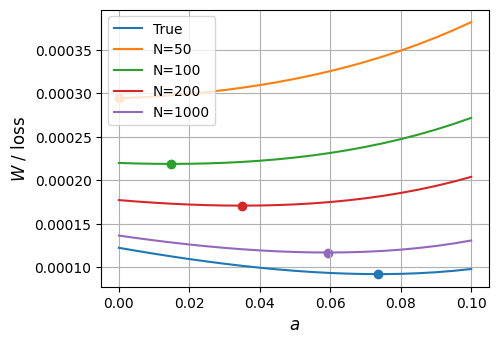

In [30]:
opt_idx = 3
param_set = np.linspace(0.0, 0.1, 21)
start = time.time()
res_btc = loss_plots_empirical_flat(logret_btc, m_btc, s_btc, 0.0, 0.0, opt_idx, param_set, Nset=[50, 100, 200, 1000], minimizer=True)
print("total: ", time.time() - start)
print(res_btc['true_sols'], res_btc['true_vals'])

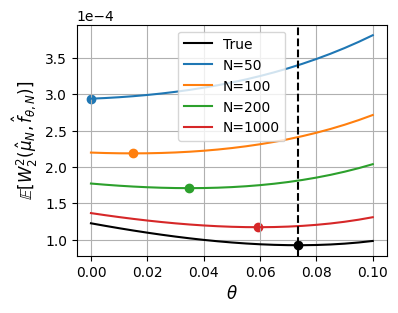

In [31]:
plot_res_loss(res_btc, r'$h$', yticks_sci=True, figsize=(4,3))#, xticks=[0, 0.05, 0.1, 0.15, 0.2])
# plt.savefig(f'./fig_loss_tukey_h_misspecified_btc.pdf', format='pdf', bbox_inches="tight", dpi=300)

bounds:  (0.06, 0.09)
param_heu: 0.07208543013222364
alpha_heu: 0.7079194036506196
param_inf: 0.07358490474407738
0.7079194036506196


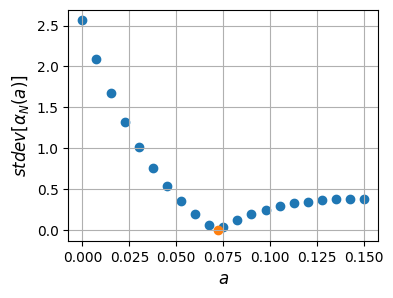

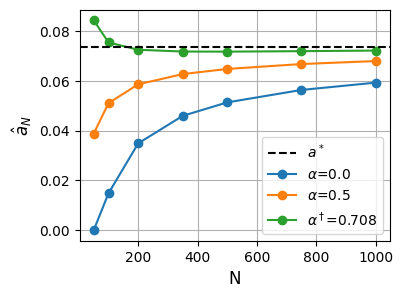

95.04836463928223


In [36]:
mu1, sigma1, g1, h1 = m_btc, s_btc, 0.0, 0.0

param_set = np.linspace(0.0, 0.15, 21)
idx = 3
N_set2 = [200, 500, 1000]#[10, 20, 50, 100]#[900, 950, 1000] #
N_set3 = [50, 100, 200, 350, 500, 750, 1000] #[10, 20, 50, 100]#
start=time.time()
res_ms_btc = get_alpha_dagger_empirical_parallel_flat(logret_btc, mu1, sigma1, g1, h1, idx, N_set2, N_set3, param_set, ver='sc')
print(time.time() - start)

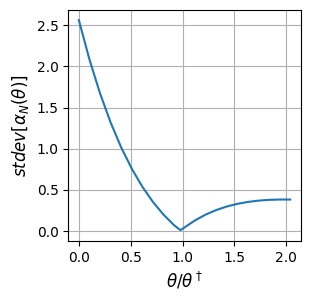

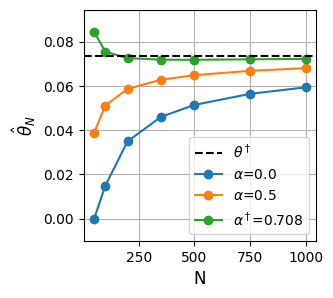

In [37]:
plot_res_alpha(res_ms_btc, 'h', datalabel='_btc', figsize=(3,3), divide=True, save=False, offset=0.01)

(-0.3, 0.25)

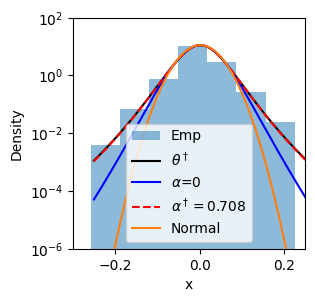

In [38]:
xspan = np.linspace(-0.25, 0.25, 1001)
plt.figure(figsize=(3,3))
plt.hist(logret_btc, label='Emp', density=True, alpha=0.5)

true_theta = np.array([m_btc, s_btc, 0, sol_btc_1d])
# true_theta = sol_btc
Nidx = 2
theta_cor = np.array([m_btc, s_btc, 0, res_ms_btc['param_corrected_a'][Nidx]])
theta_uncor = np.array([m_btc, s_btc, 0, res_ms_btc['param_uncorrected_set'][Nidx]])
xspan, pdf = plot_tukey_pdf(xspan, true_theta, color='k', text=r'$\theta^\dagger$')
xspan, pdf = plot_tukey_pdf(xspan, theta_uncor, color='b', text=r'$\alpha$=0')
xspan, pdf = plot_tukey_pdf(xspan, theta_cor, color='r', text=fr'$\alpha^\dagger={res_ms_btc["alpha_heu"]:.3f}$', ls='--')
plt.plot(xspan, norm.pdf((xspan-m_btc)/s_btc)/s_btc, label='Normal')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.yscale('log')
plt.ylim(1e-6,1e2)
plt.xlim(-0.3, 0.25)
# plt.title(f"PDF of Tukey g-and-h (N={N})")
# plt.savefig(f'./fig_pdf_tukey_h_misspecified_btc.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [39]:
np.random.seed(0)
true_theta = np.array([m_btc, s_btc, 0.0, 0.0])
theta0 = np.array([m_btc, s_btc, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 0.2, 0.001
sample_size_set = [10, 20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = 0.0

theta_trj_set_btc = {}
grad_trj_set_btc = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_trj, grad_trj = sgd_empirical_sqW2loss(logret_btc, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,2])
    theta_trj_set_btc[str(sample_size)] = theta_trj
    grad_trj_set_btc[str(sample_size)] = grad_trj

0 10
1 20
2 50
3 100
4 200
5 500
6 1000


In [41]:
np.random.seed(0)
true_theta = np.array([m_btc, s_btc, 0.0, 0.0])
theta0 = np.array([m_btc, s_btc, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 0.2, 0.001
sample_size_set = [10, 20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = res_ms_btc['alpha_heu']

theta_debias_trj_set_btc = {}
grad_debias_trj_set_btc = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_debias_trj, grad_debias_trj = sgd_empirical_sqW2loss(logret_btc, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,2], clipval=10)
    theta_debias_trj_set_btc[str(sample_size)] = theta_debias_trj
    grad_debias_trj_set_btc[str(sample_size)] = grad_debias_trj

0 10
1 20
2 50
3 100
4 200
5 500
6 1000


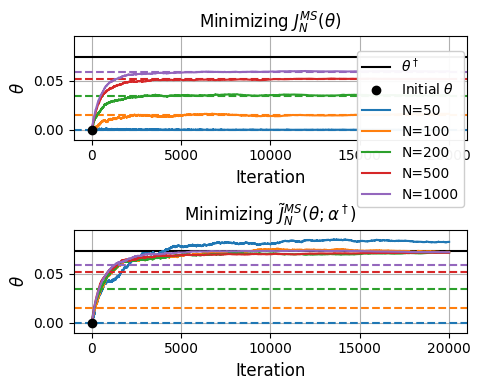

In [42]:
plt.figure(figsize=(5,4))
i=3
sample_size_set = [50, 100, 200, 500, 1000]
plt.subplot(2,1,1)
plt.axhline(res_ms_btc['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_trj_set_btc[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_btc['N_set2']:
        idx = res_ms_btc['N_set2'].index(sample_size)
        plt.axhline(res_ms_btc['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $J^{MS}_N(\theta)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([-0.01,0.095])
plt.xticks([0, 5000, 10000, 15000, 20000])

plt.subplot(2,1,2)
plt.axhline(res_ms_btc['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_debias_trj_set_btc[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_btc['N_set2']:
        idx = res_ms_btc['N_set2'].index(sample_size)
        plt.axhline(res_ms_btc['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $\tilde{J}^{MS}_N(\theta; \alpha^\dagger)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([-0.01,0.095])
plt.tight_layout()
plt.xticks([0, 5000, 10000, 15000, 20000])
# plt.legend(loc='right')
plt.legend(loc='upper right', framealpha=0.95, bbox_to_anchor=(1.01, 2.8))
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.9))
# plt.savefig(f'./fig_sgd_tukey_btc.pdf', format='pdf', bbox_inches="tight", dpi=300)

# SPY

In [43]:
spy = yf.download("SPY", period="10y", interval="1d")["Close"].dropna()
logret_spy = np.diff(np.log(spy.values).reshape(-1))

/tmp/ipykernel_7062/2371886191.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", period="10y", interval="1d")["Close"].dropna()
[*********************100%***********************]  1 of 1 completed


In [44]:
logret_spy.shape

(2513,)

In [45]:
m_spy = logret_spy.mean()
s_spy = logret_spy.std()

In [46]:
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_spy_2d, val_spy_2d = numerical_sol_true_loss_empirical_2d(logret_spy, m_spy, s_spy,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_spy_2d, val_spy_2d)

[-0.05531546  0.0841723 ] 1.3076165274365152e-05


In [47]:
idx=3
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_spy_1d, val_spy_1d = numerical_sol_true_loss_empirical_1d(logret_spy, m_spy, s_spy, 0.0, 0.0, idx,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_spy_1d, val_spy_1d)

0.0851275503309758 1.355019148961364e-05


dist true:  68.73211240768433
dist emp:  14.442109823226929
solve emp:  2.3966777324676514
solve true:  25.846769094467163
total:  111.46740412712097
0.0851275503309758 1.355019148961364e-05


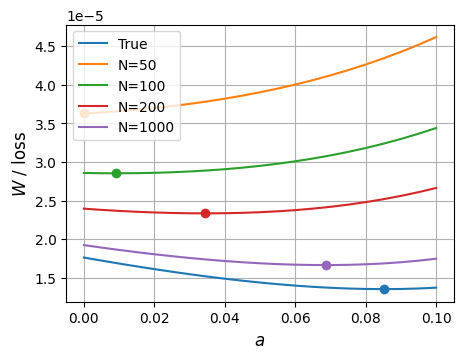

In [48]:
opt_idx = 3
param_set = np.linspace(0.0, 0.1, 21)
start = time.time()
res_spy = loss_plots_empirical_flat(logret_spy, m_spy, s_spy, 0.0, 0.0, opt_idx, param_set, Nset=[50, 100, 200, 1000], minimizer=True)
print("total: ", time.time() - start)
print(res_spy['true_sols'], res_spy['true_vals'])

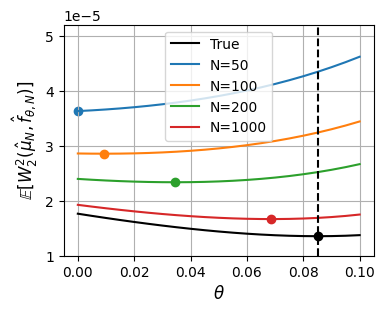

In [49]:
plot_res_loss(res_spy, r'$h$', yticks_sci=True, figsize=(4,3), ylim=[1e-5, 5.2e-5])#, xticks=[0, 0.05, 0.1, 0.15, 0.2])
# plt.savefig(f'./fig_loss_tukey_h_misspecified_spy.pdf', format='pdf', bbox_inches="tight", dpi=300)

bounds:  (0.075, 0.105)
param_heu: 0.08793252804015383
alpha_heu: 0.8630918611982937
param_inf: 0.0851275503309758
0.8630918611982937


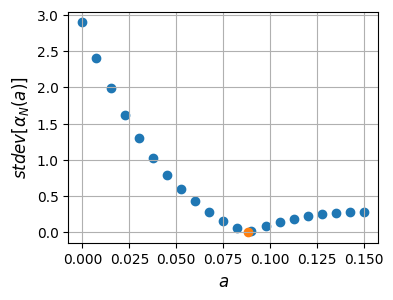

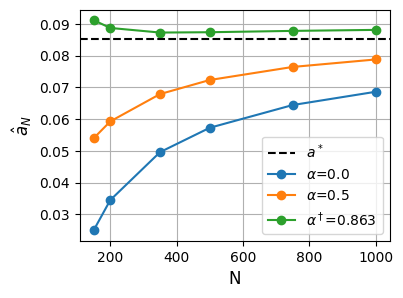

85.86945676803589


In [50]:
mu1, sigma1, g1, h1 = m_spy, s_spy, 0.0, 0.0

param_set = np.linspace(0.0, 0.15, 21)
idx = 3
N_set2 = [200, 500, 1000]#[10, 20, 50, 100]#[900, 950, 1000] #
N_set3 = [150, 200, 350, 500, 750, 1000] #[10, 20, 50, 100]#
start=time.time()
res_ms_spy = get_alpha_dagger_empirical_parallel_flat(logret_spy, mu1, sigma1, g1, h1, idx, N_set2, N_set3, param_set, ver='sc')
print(time.time() - start)

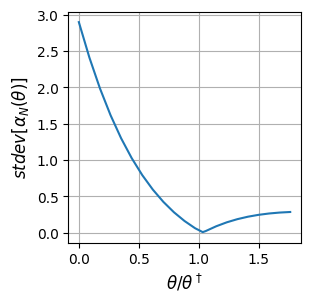

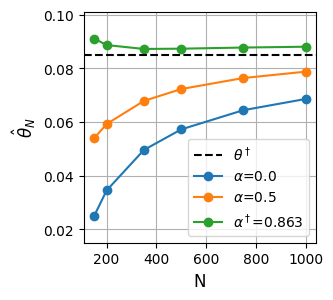

In [73]:
plot_res_alpha(res_ms_spy, 'h', datalabel='_spy', figsize=(3,3), divide=True, save=False, offset=0.01)

(1e-06, 100.0)

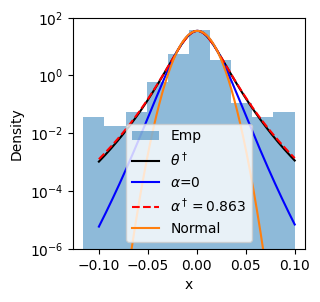

In [52]:
xspan = np.linspace(-0.1, 0.1, 1001)
plt.figure(figsize=(3,3))
plt.hist(logret_spy, label='Emp', density=True, alpha=0.5)

true_theta_2d = np.array([m_spy, s_spy, sol_spy_2d[0], sol_spy_2d[1]])
true_theta = np.array([m_spy, s_spy, 0, sol_spy_1d])
Nidx = 1
theta_cor = np.array([m_spy, s_spy, 0, res_ms_spy['param_corrected_a'][Nidx]])
theta_uncor = np.array([m_spy, s_spy, 0, res_ms_spy['param_uncorrected_set'][Nidx]])
xspan, pdf = plot_tukey_pdf(xspan, true_theta, color='k', text=r'$\theta^\dagger$')
xspan, pdf = plot_tukey_pdf(xspan, theta_uncor, color='b', text=r'$\alpha$=0')
xspan, pdf = plot_tukey_pdf(xspan, theta_cor, color='r', text=fr'$\alpha^\dagger={res_ms_spy["alpha_heu"]:.3f}$', ls='--')
plt.plot(xspan, norm.pdf((xspan-m_spy)/s_spy)/s_spy, label='Normal')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.yscale('log')
plt.ylim(1e-6,1e2)
# plt.grid()
# plt.xlim(-0.3, 0.25)
# plt.savefig(f'./fig_pdf_tukey_h_misspecified_spy.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [53]:
s_btc, s_spy

(0.0356183547185634, 0.011385809377935204)

In [54]:
np.random.seed(0)
true_theta = np.array([m_spy, s_spy, 0.0, 0.0])
theta0 = np.array([m_spy, s_spy, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 1.5, 0.001
sample_size_set = [150, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = 0.0

theta_trj_set_spy = {}
grad_trj_set_spy = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_trj, grad_trj = sgd_empirical_sqW2loss(logret_spy, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,2])
    theta_trj_set_spy[str(sample_size)] = theta_trj
    grad_trj_set_spy[str(sample_size)] = grad_trj

0 150
1 200
2 500
3 1000


In [55]:
np.random.seed(0)
true_theta = np.array([m_spy, s_spy, 0.0, 0.0])
theta0 = np.array([m_spy, s_spy, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 1.5, 0.001
sample_size_set = [150, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = res_ms_spy['alpha_heu']

theta_debias_trj_set_spy = {}
grad_debias_trj_set_spy = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_debias_trj, grad_debias_trj = sgd_empirical_sqW2loss(logret_spy, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,2], clipval=10)
    theta_debias_trj_set_spy[str(sample_size)] = theta_debias_trj
    grad_debias_trj_set_spy[str(sample_size)] = grad_debias_trj

0 150
1 200
2 500
3 1000


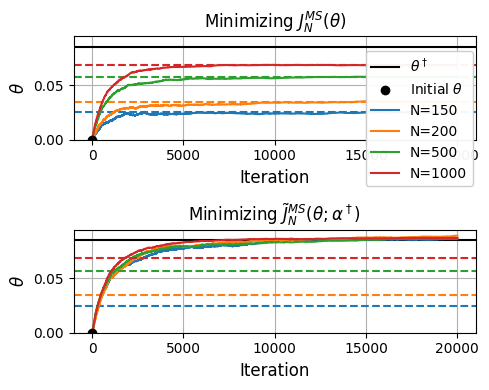

In [56]:
plt.figure(figsize=(5,4))
i=3
sample_size_set = [150, 200, 500, 1000]
plt.subplot(2,1,1)
plt.axhline(res_ms_spy['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_trj_set_spy[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_spy['N_set2']:
        idx = res_ms_spy['N_set2'].index(sample_size)
        plt.axhline(res_ms_spy['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $J^{MS}_N(\theta)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([0,0.095])
plt.xticks([0, 5000, 10000, 15000, 20000])

plt.subplot(2,1,2)
plt.axhline(res_ms_spy['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_debias_trj_set_spy[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_spy['N_set2']:
        idx = res_ms_spy['N_set2'].index(sample_size)
        plt.axhline(res_ms_spy['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $\tilde{J}^{MS}_N(\theta; \alpha^\dagger)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([0,0.095])
plt.tight_layout()
plt.xticks([0, 5000, 10000, 15000, 20000])
# plt.legend(loc='right')
plt.legend(loc='upper right', framealpha=0.95, bbox_to_anchor=(1.01, 2.8))
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.9))
# plt.savefig(f'./fig_sgd_tukey_spy.pdf', format='pdf', bbox_inches="tight", dpi=300)

# Diamond

In [57]:
import seaborn as sns, numpy as np
diamonds = sns.load_dataset("diamonds")
x_dia = diamonds["price"].dropna().to_numpy().astype(float)

In [58]:
np.random.seed(0)
x_dia_ss = np.random.choice(x_dia/1000, size=4000, replace=False)

In [59]:
m_dia = x_dia_ss.mean()
s_dia = x_dia_ss.std()

In [60]:
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_dia_2d, val_dia_2d = numerical_sol_true_loss_empirical_2d(x_dia_ss, m_dia, s_dia,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_dia_2d, val_dia_2d)

[0.30459473 0.        ] 1.77396987995904


In [61]:
idx=2
with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
    sol_dia_1d, val_dia_1d = numerical_sol_true_loss_empirical_1d(x_dia_ss, m_dia, s_dia, 0.3, 0.0, idx,
                         ver = 'sc', use_par=True, pool=pool)
    print(sol_dia_1d, val_dia_1d)

0.304631343853145 1.7739698517591904


dist true:  108.23466420173645
dist emp:  17.436075925827026
solve emp:  2.4274730682373047
solve true:  37.61108732223511
total:  165.7646472454071
0.304631343853145 1.7739698517591904


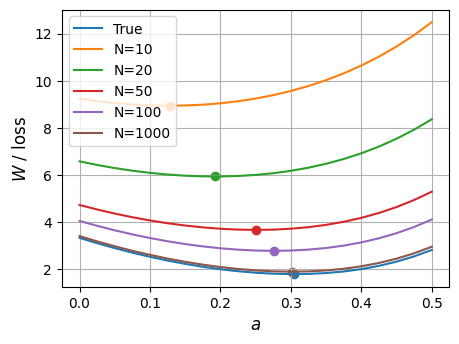

In [64]:
opt_idx = 2
param_set = np.linspace(0.0, 0.5, 21)
start = time.time()
res_dia = loss_plots_empirical_flat(x_dia_ss, m_dia, s_dia, 0.0, 0.0, opt_idx, param_set, Nset=[10, 20, 50, 100, 1000], minimizer=True)
print("total: ", time.time() - start)
print(res_dia['true_sols'], res_dia['true_vals'])

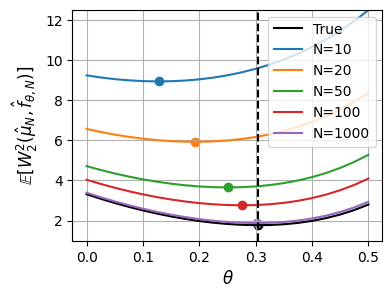

In [65]:
plot_res_loss(res_dia, r'$g$', figsize=(4,3), ylim=[1, 12.5], loc='upper right')#, xticks=[0, 0.05, 0.1, 0.15, 0.2])
# plt.savefig(f'./fig_loss_tukey_g_misspecified_diamond.pdf', format='pdf', bbox_inches="tight", dpi=300)

bounds:  (0.26, 0.33999999999999997)
param_heu: 0.30650797729995555
alpha_heu: 0.3349906300736782
param_inf: 0.304631343853145
0.3349906300736782


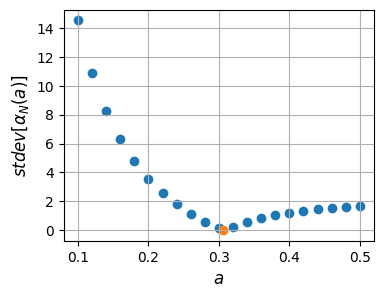

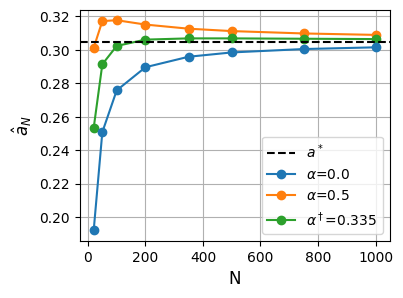

99.18417739868164


In [66]:
mu1, sigma1, g1, h1 = m_dia, s_dia, 0.0, 0.0

param_set = np.linspace(0.1, 0.5, 21)
idx = 2
N_set2 = [200, 500, 1000]#[10, 20, 50, 100]#[900, 950, 1000] #
N_set3 = [20, 50, 100, 200, 350, 500, 750, 1000] #[10, 20, 50, 100]#
start=time.time()
res_ms_dia = get_alpha_dagger_empirical_parallel_flat(x_dia_ss, mu1, sigma1, g1, h1, idx, N_set2, N_set3, param_set, ver='sc')
print(time.time() - start)

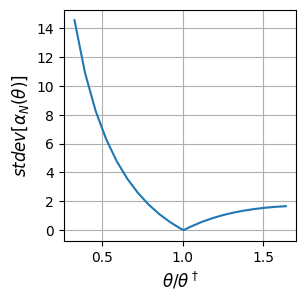

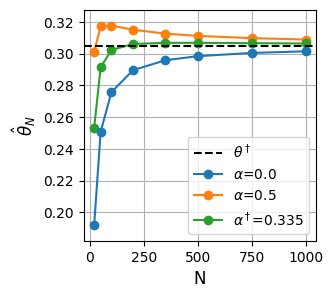

In [67]:
plot_res_alpha(res_ms_dia, 'g', datalabel='_diamond', figsize=(3,3), divide=True, save=False, offset=0.01)

(1e-06, 1.0)

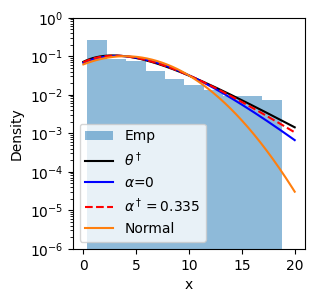

In [68]:
xspan = np.linspace(0, 20, 1001)
plt.figure(figsize=(3,3))
plt.hist(x_dia_ss, label='Emp', density=True, alpha=0.5)

true_theta_2d = np.array([m_dia, s_dia, sol_dia_2d[0], sol_dia_2d[1]])
true_theta = np.array([m_dia, s_dia, sol_dia_1d, 0])
Nidx = 0
theta_cor = np.array([m_dia, s_dia, res_ms_dia['param_corrected_a'][Nidx], 0])
theta_uncor = np.array([m_dia, s_dia, res_ms_dia['param_uncorrected_set'][Nidx], 0])
xspan, pdf = plot_tukey_pdf(xspan, true_theta, color='k', text=r'$\theta^\dagger$')
xspan, pdf = plot_tukey_pdf(xspan, theta_uncor, color='b', text=r'$\alpha$=0')
xspan, pdf = plot_tukey_pdf(xspan, theta_cor, color='r', text=fr'$\alpha^\dagger={res_ms_dia["alpha_heu"]:.3f}$', ls='--')
plt.plot(xspan, norm.pdf((xspan-m_dia)/s_dia)/s_dia, label='Normal')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.yscale('log')
plt.ylim(1e-6,1e0)
# plt.grid()
# plt.xlim(-0.3, 0.25)
# plt.savefig(f'./fig_pdf_tukey_g_misspecified_diamond.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [69]:
s_dia

3.988190639362542

In [70]:
np.random.seed(0)
true_theta = np.array([m_dia, s_dia, 0.0, 0.0])
theta0 = np.array([m_dia, s_dia, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 0.001, 0.001
sample_size_set = [20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = 0.0

theta_trj_set_dia = {}
grad_trj_set_dia = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_trj, grad_trj = sgd_empirical_sqW2loss(x_dia_ss, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,3])
    theta_trj_set_dia[str(sample_size)] = theta_trj
    grad_trj_set_dia[str(sample_size)] = grad_trj

0 20
1 50
2 100
3 200
4 500
5 1000


In [71]:
np.random.seed(0)
true_theta = np.array([m_dia, s_dia, 0.0, 0.0])
theta0 = np.array([m_dia, s_dia, 0.0, 0.0])
n_iter, eta0, gamma = 20000, 0.001, 0.001
sample_size_set = [20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = res_ms_dia['alpha_heu']

theta_debias_trj_set_dia = {}
grad_debias_trj_set_dia = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_debias_trj, grad_debias_trj = sgd_empirical_sqW2loss(x_dia_ss, theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1,3])
    theta_debias_trj_set_dia[str(sample_size)] = theta_debias_trj
    grad_debias_trj_set_dia[str(sample_size)] = grad_debias_trj

0 20
1 50
2 100
3 200
4 500
5 1000


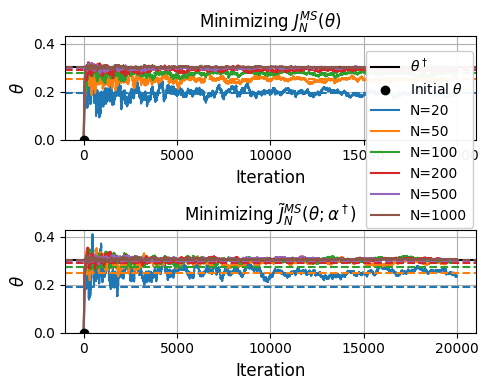

In [72]:
plt.figure(figsize=(5,4))
i=2
sample_size_set = [20, 50, 100, 200, 500, 1000]
plt.subplot(2,1,1)
plt.axhline(res_ms_dia['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_trj_set_dia[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_dia['N_set2']:
        idx = res_ms_dia['N_set2'].index(sample_size)
        plt.axhline(res_ms_dia['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $J^{MS}_N(\theta)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([0,0.43])
plt.xticks([0, 5000, 10000, 15000, 20000])

plt.subplot(2,1,2)
plt.axhline(res_ms_dia['param_inf'], color='k', linestyle='-', label=fr'$\theta^\dagger$')
plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
for j, sample_size in enumerate(sample_size_set):
    theta_trj = theta_debias_trj_set_dia[str(sample_size)]
    plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
    if sample_size in res_ms_dia['N_set2']:
        idx = res_ms_dia['N_set2'].index(sample_size)
        plt.axhline(res_ms_dia['param_uncorrected_set'][idx], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
plt.grid()
plt.title(r'Minimizing $\tilde{J}^{MS}_N(\theta; \alpha^\dagger)$')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$\theta$', fontsize=12)
plt.ylim([0,0.43])
plt.tight_layout()
plt.xticks([0, 5000, 10000, 15000, 20000])
# plt.legend(loc='right')
plt.legend(loc='upper right', framealpha=0.95, bbox_to_anchor=(1.01, 2.8))
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.9))
# plt.savefig(f'./fig_sgd_tukey_diamond.pdf', format='pdf', bbox_inches="tight", dpi=300)